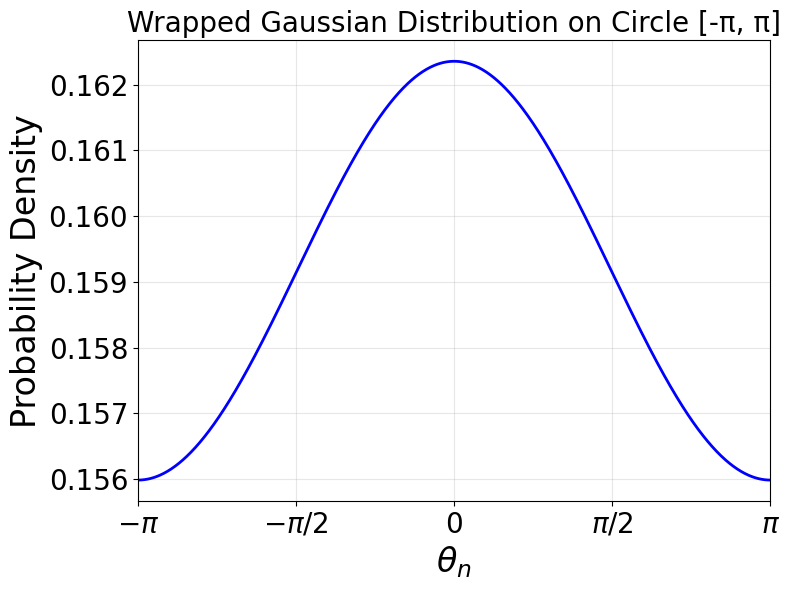

In [1]:
# Global font size variables for all plots
LABEL_FONTSIZE = 24    # For axis labels (x-label, y-label)
TICK_FONTSIZE = 20     # For axis tick numbers
TITLE_FONTSIZE = 20    # For plot titles

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises

# Create x values (theta_n) from -pi to pi
theta_n = np.linspace(-np.pi, np.pi, 1000)

# Create wrapped Gaussian (von Mises distribution) on the circle
mu = 0  # mean direction (in radians)
kappa = 0.02  # concentration parameter (higher = more concentrated)
wrapped_gaussian = vonmises.pdf(theta_n, kappa, loc=mu)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(theta_n, wrapped_gaussian, 'b-', linewidth=2)
plt.xlabel(r'$\theta_n$', fontsize=LABEL_FONTSIZE)
plt.ylabel('Probability Density', fontsize=LABEL_FONTSIZE)
plt.title('Wrapped Gaussian Distribution on Circle [-π, π]', fontsize=TITLE_FONTSIZE)
plt.xlim(-np.pi, np.pi)
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], 
           [r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'], fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


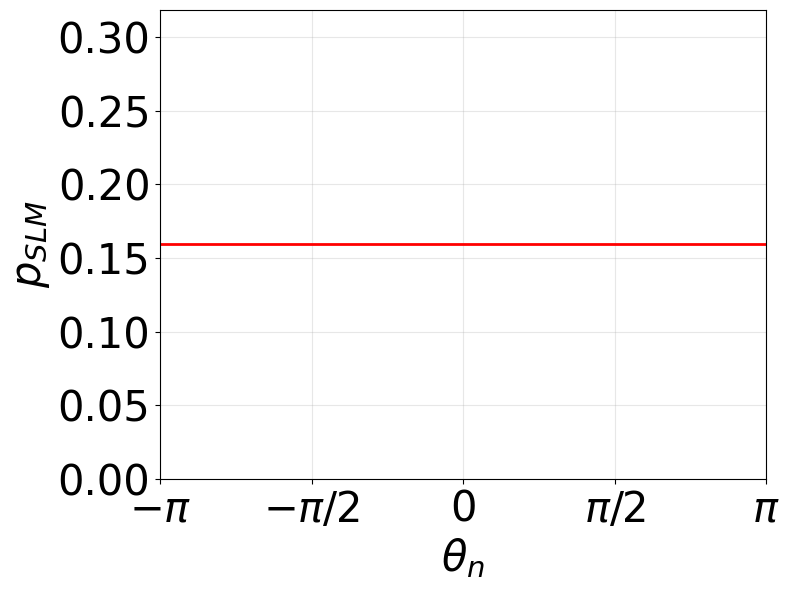

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create x values (theta_n) from -pi to pi
theta_n = np.linspace(-np.pi, np.pi, 1000)

# Create uniform distribution on the circle
uniform_density = np.ones_like(theta_n) / (2 * np.pi)  # Normalize so integral = 1

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(theta_n, uniform_density, 'r-', linewidth=2)
plt.xlabel(r'$\theta_n$', fontsize=30)
plt.ylabel(r'$p_{SLM}$', fontsize=30)
# plt.title('Uniform Distribution on Circle [-π, π]', fontsize=TITLE_FONTSIZE)
plt.xlim(-np.pi, np.pi)
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], 
           [r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'], fontsize=30)
plt.yticks(fontsize=30)
# Fix y-axis to center the line in the middle of the figure
plt.ylim(0, uniform_density[0] * 2.0)  # Center the line by using 2x the density value
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [3]:

# JAX + plotting
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Interactive plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px



In [4]:
# -----------------------------
# 5) Fancy 3D Visualization: Complex Reservoir Distribution with Marginalizations
# -----------------------------

# --- Helper functions ---
def kde_1d(samples, grid, bandwidth=None):
    """1D Gaussian KDE for density estimation"""
    x = jnp.asarray(samples).reshape(-1, 1)
    g = jnp.asarray(grid).reshape(1, -1)
    n = x.shape[0]
    if bandwidth is None:
        std = jnp.std(samples)
        bw = 1.06 * std * (n ** (-1/5))
        bw = jnp.maximum(bw, 1e-6)
    else:
        bw = bandwidth
    z = (g - x) / bw
    phi = jnp.exp(-0.5 * z**2) / jnp.sqrt(2 * jnp.pi)
    dens = jnp.mean(phi, axis=0) / bw
    return dens

def central_moments(x):
    """Compute central moments of a distribution"""
    mu = jnp.mean(x)
    xc = x - mu
    m2 = jnp.mean(xc**2)
    m3 = jnp.mean(xc**3)
    m4 = jnp.mean(xc**4)
    return mu, m2, m3, m4

def create_fancy_reservoir(key, n=5000):
    """Create a more complex and visually interesting 2D reservoir distribution"""
    keys = jax.random.split(key, 6)
    
    # Component 1: Elongated Gaussian (main body)
    mean1 = jnp.array([0.0, 0.0])
    # Create elongated covariance matrix
    angle1 = jnp.pi/6  # 30 degrees
    R1 = jnp.array([[jnp.cos(angle1), -jnp.sin(angle1)], 
                    [jnp.sin(angle1), jnp.cos(angle1)]])
    D1 = jnp.array([[2.5, 0], [0, 0.8]])  # Elongated
    cov1 = R1 @ D1 @ R1.T
    
    # Component 2: Circular blob (offset)
    mean2 = jnp.array([3.0, 2.0])
    cov2 = jnp.array([[0.6, 0.1], [0.1, 0.6]])
    
    # Component 3: Another elongated component (different orientation)
    mean3 = jnp.array([-1.5, 2.5])
    angle3 = -jnp.pi/3  # -60 degrees
    R3 = jnp.array([[jnp.cos(angle3), -jnp.sin(angle3)], 
                    [jnp.sin(angle3), jnp.cos(angle3)]])
    D3 = jnp.array([[1.8, 0], [0, 0.5]])
    cov3 = R3 @ D3 @ R3.T
    
    # Component 4: Small tight cluster
    mean4 = jnp.array([1.0, -2.0])
    cov4 = jnp.array([[0.3, -0.1], [-0.1, 0.4]])
    
    # Mixing weights (unequal for more interesting structure)
    weights = [0.4, 0.25, 0.25, 0.1]
    n_components = [int(w * n) for w in weights]
    n_components[-1] = n - sum(n_components[:-1])  # Ensure exact total
    
    # Sample from each component
    samples_list = []
    
    # Component 1
    L1 = jnp.linalg.cholesky(cov1)
    z1 = jax.random.normal(keys[0], (n_components[0], 2)) @ L1.T + mean1
    samples_list.append(z1)
    
    # Component 2
    L2 = jnp.linalg.cholesky(cov2)
    z2 = jax.random.normal(keys[1], (n_components[1], 2)) @ L2.T + mean2
    samples_list.append(z2)
    
    # Component 3
    L3 = jnp.linalg.cholesky(cov3)
    z3 = jax.random.normal(keys[2], (n_components[2], 2)) @ L3.T + mean3
    samples_list.append(z3)
    
    # Component 4
    L4 = jnp.linalg.cholesky(cov4)
    z4 = jax.random.normal(keys[3], (n_components[3], 2)) @ L4.T + mean4
    samples_list.append(z4)
    
    # Combine and shuffle
    all_samples = jnp.vstack(samples_list)
    indices = jax.random.permutation(keys[4], n)
    
    return all_samples[indices]

# Create the fancy reservoir
fancy_key = jax.random.PRNGKey(42)
fancy_reservoir = create_fancy_reservoir(fancy_key, n=5000)

print("Created fancy reservoir with 4 components and complex structure")
print(f"Reservoir shape: {fancy_reservoir.shape}")
print(f"X range: [{jnp.min(fancy_reservoir[:, 0]):.2f}, {jnp.max(fancy_reservoir[:, 0]):.2f}]")
print(f"Y range: [{jnp.min(fancy_reservoir[:, 1]):.2f}, {jnp.max(fancy_reservoir[:, 1]):.2f}]")

# Create 3D visualization using density estimation
from mpl_toolkits.mplot3d import Axes3D

# Create a grid for density estimation
x_range = jnp.linspace(jnp.min(fancy_reservoir[:, 0])-1, jnp.max(fancy_reservoir[:, 0])+1, 50)
y_range = jnp.linspace(jnp.min(fancy_reservoir[:, 1])-1, jnp.max(fancy_reservoir[:, 1])+1, 50)
X, Y = jnp.meshgrid(x_range, y_range)

# Simple 2D density estimation using Gaussian kernels
def gaussian_2d_kde(samples, grid_x, grid_y, bandwidth=0.3):
    """2D Gaussian KDE for density estimation"""
    n_samples = samples.shape[0]
    density = jnp.zeros_like(grid_x)
    
    for i in range(n_samples):
        # Gaussian kernel centered at each sample point
        diff_x = grid_x - samples[i, 0]
        diff_y = grid_y - samples[i, 1]
        kernel = jnp.exp(-(diff_x**2 + diff_y**2) / (2 * bandwidth**2))
        density += kernel
    
    return density / (n_samples * 2 * jnp.pi * bandwidth**2)

# Compute density
print("Computing 2D density...")
Z = gaussian_2d_kde(fancy_reservoir, X, Y, bandwidth=0.4)

# Create interactive 2-subplot visualization with plotly
# Define 2 non-orthogonal marginalization directions for clarity
directions = [
    (jnp.array([0.8, 0.6]), "red"),      # ~37 degrees
    (jnp.array([0.3, 0.954]), "blue")    # ~72 degrees
]

# Use a finer grid for smoother surface
x_fine = jnp.linspace(jnp.min(fancy_reservoir[:, 0])-1, jnp.max(fancy_reservoir[:, 0])+1, 80)
y_fine = jnp.linspace(jnp.min(fancy_reservoir[:, 1])-1, jnp.max(fancy_reservoir[:, 1])+1, 80)
X_fine, Y_fine = jnp.meshgrid(x_fine, y_fine)

# Compute smoother density with better bandwidth
Z_fine = gaussian_2d_kde(fancy_reservoir, X_fine, Y_fine, bandwidth=0.5)

# Create subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('3D Reservoir Distribution', '3D Samples with Marginal Distributions'),
    specs=[[{'type': 'surface'}, {'type': 'scatter3d'}]],
    horizontal_spacing=0.1
)

# Update subplot title font sizes
fig.update_annotations(font_size=LABEL_FONTSIZE)

# Left subplot: 3D density surface
surface = go.Surface(
    x=np.array(X_fine),
    y=np.array(Y_fine), 
    z=np.array(Z_fine),
    colorscale='Plasma',
    opacity=0.8,
    name='Density Surface',
    showscale=False
)

# Add contour lines at the base
contour = go.Surface(
    x=np.array(X_fine),
    y=np.array(Y_fine),
    z=np.zeros_like(Z_fine),
    surfacecolor=np.array(Z_fine),
    colorscale='Plasma',
    opacity=0.3,
    showscale=False,
    contours=dict(
        z=dict(show=True, usecolormap=True, highlightcolor="white", project_z=True)
    )
)

fig.add_trace(surface, row=1, col=1)
fig.add_trace(contour, row=1, col=1)

# Right subplot: 3D scatter with marginal distributions
# Plot the sample points in 3D (z=0 plane)
scatter_points = go.Scatter3d(
    x=np.array(fancy_reservoir[:, 0]),
    y=np.array(fancy_reservoir[:, 1]),
    z=np.zeros(len(fancy_reservoir)),
    mode='markers',
    marker=dict(size=1, color='gray', opacity=0.3),
    name='Reservoir Points',
    showlegend=True
)
fig.add_trace(scatter_points, row=1, col=2)

# For each direction, plot the marginal distribution as a 3D curve
for i, (direction, color) in enumerate(directions):
    # Project samples onto the direction
    projections = fancy_reservoir @ direction
    
    # Create 1D density
    proj_range = jnp.linspace(jnp.min(projections)-0.5, jnp.max(projections)+0.5, 100)
    density_1d = kde_1d(projections, proj_range, bandwidth=0.3)
    
    # Scale density for 3D visualization
    density_scaled = density_1d * 3.0  # Scale factor for visibility
    
    # Create 3D coordinates for the marginal curve
    curve_x = []
    curve_y = []
    curve_z = []
    
    for proj_val, dens_val in zip(proj_range, density_scaled):
        # Point on the projection line
        base_point = proj_val * direction
        curve_x.append(base_point[0])
        curve_y.append(base_point[1])
        curve_z.append(dens_val)  # Height represents density
    
    # Plot the marginal distribution as a 3D curve
    marginal_curve = go.Scatter3d(
        x=curve_x,
        y=curve_y,
        z=curve_z,
        mode='lines',
        line=dict(color=color, width=6),
        name=f'Marginal {i+1}',
        showlegend=True
    )
    fig.add_trace(marginal_curve, row=1, col=2)
    
    # Draw the projection line on the base plane
    proj_line_range = jnp.linspace(jnp.min(proj_range), jnp.max(proj_range), 50)
    line_x = proj_line_range * direction[0]
    line_y = proj_line_range * direction[1]
    line_z = np.zeros(len(proj_line_range))
    
    projection_line = go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode='lines',
        line=dict(color=color, width=3, dash='dash'),
        name=f'Projection {i+1}',
        showlegend=False
    )
    fig.add_trace(projection_line, row=1, col=2)
    
    # Add vertical lines connecting some points from base to curve
    for j in range(0, len(proj_range), 15):  # Every 15th point
        base_point = proj_range[j] * direction
        vertical_line = go.Scatter3d(
            x=[base_point[0], base_point[0]],
            y=[base_point[1], base_point[1]],
            z=[0, density_scaled[j]],
            mode='lines',
            line=dict(color=color, width=1),
            opacity=0.3,
            showlegend=False
        )
        fig.add_trace(vertical_line, row=1, col=2)

# Set axis limits for consistency
x_min, x_max = float(jnp.min(fancy_reservoir[:, 0])-1), float(jnp.max(fancy_reservoir[:, 0])+1)
y_min, y_max = float(jnp.min(fancy_reservoir[:, 1])-1), float(jnp.max(fancy_reservoir[:, 1])+1)

# Update layout for better interactivity
fig.update_layout(
    title_text="Interactive 3D Reservoir Visualization",
    title_x=0.5,
    title_font_size=TITLE_FONTSIZE,
    width=1400,
    height=700,
    scene=dict(
        xaxis_title='X1',
        yaxis_title='X2',
        zaxis_title='p<sub>R</sub>',
        xaxis=dict(range=[x_min, x_max], title_font_size=LABEL_FONTSIZE, tickfont_size=TICK_FONTSIZE),
        yaxis=dict(range=[y_min, y_max], title_font_size=LABEL_FONTSIZE, tickfont_size=TICK_FONTSIZE),
        zaxis=dict(title_font_size=LABEL_FONTSIZE, tickfont_size=TICK_FONTSIZE),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    scene2=dict(
        xaxis_title='X1',
        yaxis_title='X2',
        zaxis_title='p<sub>marg</sub>',
        xaxis=dict(range=[x_min, x_max], title_font_size=LABEL_FONTSIZE, tickfont_size=TICK_FONTSIZE),
        yaxis=dict(range=[y_min, y_max], title_font_size=LABEL_FONTSIZE, tickfont_size=TICK_FONTSIZE),
        zaxis=dict(title_font_size=LABEL_FONTSIZE, tickfont_size=TICK_FONTSIZE),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.0))
    ),
    showlegend=True,
    legend=dict(x=1.02, y=0.8, font_size=LABEL_FONTSIZE)
)

# Show the interactive plot
fig.show()

# Print some statistics about the marginals
print("\n=== MARGINAL STATISTICS ===")
for i, (direction, color) in enumerate(directions):
    projections = fancy_reservoir @ direction
    mu, var, skew, kurt = central_moments(projections)
    name = f"Direction {i+1}"
    print(f"{name:15s}: μ={mu:6.3f}, σ²={var:6.3f}, skew={skew:6.3f}, kurt={kurt:6.3f}")

print(f"\nThe fancy reservoir shows how different projection directions")
print(f"reveal completely different 1D marginal distributions!")
print(f"This demonstrates the richness of high-dimensional reservoir computing.")


2025-10-15 23:48:11.920992: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Created fancy reservoir with 4 components and complex structure
Reservoir shape: (5000, 2)
X range: [-5.47, 5.30]
Y range: [-4.00, 6.89]
Computing 2D density...



=== MARGINAL STATISTICS ===
Direction 1    : μ= 0.923, σ²= 3.671, skew= 2.561, kurt=33.408
Direction 2    : μ= 1.021, σ²= 3.201, skew=-1.151, kurt=21.618

The fancy reservoir shows how different projection directions
reveal completely different 1D marginal distributions!
This demonstrates the richness of high-dimensional reservoir computing.
